In [230]:
from util import *
import pandas as pd
import matplotlib.pyplot as plt

## Import Feaature Extracted Data

In [ ]:
# run data_feature.ipynb first
df = pd.read_csv("dataset/eeg_features.csv")
participants_df = pd.read_csv("dataset/participants.tsv", sep='\t')

In [121]:
all_data = []
num_row_per_subject = 118
num_subject = 88
mean_var_iqr_columns = df.columns[df.columns.str.contains('Mean') | df.columns.str.contains('Var') | df.columns.str.contains('IQR')].to_list()

for ith_subject in range(num_subject):
    all_data.append(df.iloc[ith_subject*num_row_per_subject:(ith_subject+1)*num_row_per_subject,:].reset_index().drop(columns=['index']+mean_var_iqr_columns))

## Re-construct DataFrame structure as PA3 used

In [197]:
# "Delta" "Theta" "Alpha" "Beta" "Gamma"
band_name = ["Delta","Theta","Alpha","Beta","Gamma"]

          # 0    1          # 0 AZ  1 FTD  2 Healthy
# band -> train_test -> class(list of channel)
All_band = [[[[],[],[]],[[],[],[]]],
            [[[],[],[]],[[],[],[]]],
            [[[],[],[]],[[],[],[]]],
            [[[],[],[]],[[],[],[]]],
            [[[],[],[]],[[],[],[]]]
            ]
band_dictionary = {band_name[i]:i for i in range(len(band_name))}
num_channel = 19


In [43]:
for band in band_name:
    for subject in all_data:

        temp = [] # channel--datapoints
        current_band_df = subject[subject.columns[subject.columns.str.contains(band)]]  # eg. subject 1 Delta band

        for ch in range(num_channel):
            temp.append(current_band_df.iloc[:,ch].to_numpy())

        if subject['train_test'][0] == 'Train':
            All_band[band_dictionary[band]][0][subject['Label'][0]].append(temp)
        else:
            All_band[band_dictionary[band]][1][subject['Label'][0]].append(temp)


In [44]:
# The code given in PA3 uses train_data_1 for numTrials_2
# Which is not suit in my condition, since my trials are not the same amount between two classes
def train_(train_data_1, train_data_2, numFilt):

    numTrials_1 = np.size(train_data_1,0)
    numTrials_2 = np.size(train_data_2,0)

    # train the CCACSP filters 
    ccacsp_filts = calc_CCACSP(train_data_1, train_data_2, numFilt)

    # extract the features
    train_filt_1 = apply_CCACSP(train_data_1, ccacsp_filts, numFilt)
    train_logP_1  = np.squeeze(np.log(np.var(train_filt_1, axis=2)))

    train_filt_2 = apply_CCACSP(train_data_2, ccacsp_filts, numFilt)
    train_logP_2  = np.squeeze(np.log(np.var(train_filt_2, axis=2)))

    # define the classifier
    clf = lda.LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
    
    X = np.concatenate((train_logP_1, train_logP_2), axis=0)

    y1 = np.zeros(numTrials_1)
    y2 = np.ones(numTrials_2)
    y = np.concatenate((y1, y2))

    # train the classifier 
    clf.fit(X, y)

    return ccacsp_filts, clf

## Train and Test CSP classifier with different csp_per_class

In [153]:
def train_test(csp_per_class, n_filters, band_df):
    trainIdx = 0
    testIdx = 1
    n_filters = n_filters
    train_size = (participants_df['Set']=='Train').sum()
    test_size = (participants_df['Set']=='Test').sum()
    csp_per_class = csp_per_class
    All_band = band_df

    band_score_train =np.zeros((train_size, n_filters))
    band_score_test = np.zeros((test_size, n_filters))

    for band in range(n_filters):
        AZ_train = np.array(All_band[band][0][0])
        FTD_train = np.array(All_band[band][0][1])
        Health_train = np.array(All_band[band][0][2])
        train_data = np.concatenate((AZ_train,FTD_train,Health_train), axis=0)

        AZ_test = np.array(All_band[band][1][0])
        FTD_test = np.array(All_band[band][1][1])
        Health_test = np.array(All_band[band][1][2])
        test_data = np.concatenate((AZ_test,FTD_test,Health_test), axis=0)

        # AZ FTD classifier
        AZ_FTD_csp_filts, AZ_FTD_clf = train_(AZ_train, FTD_train, csp_per_class)

        # AZ Health classifier
        AZ_Health_csp_filts, AZ_Health_clf = train_(AZ_train, Health_train, csp_per_class)

        # FTD Health classifier
        FTD_Health_csp_filts, FTD_Health_clf = train_(FTD_train, Health_train, csp_per_class)

        # Train Prediction
        AZ_FTD_train_prob = test(train_data, AZ_FTD_csp_filts, AZ_FTD_clf)
        AZ_Health_train_prob = test(train_data, AZ_Health_csp_filts, AZ_Health_clf)
        FTD_Health_train_prob = test(train_data, FTD_Health_csp_filts, FTD_Health_clf)

        AZ_FTD = [0 if boolean else 1 for boolean in AZ_FTD_train_prob>0.5]
        AZ_Health = [0 if boolean else 2 for boolean in AZ_Health_train_prob>0.5]
        FTD_Health = [1 if boolean else 2 for boolean in FTD_Health_train_prob>0.5]

        train_predict = []

        for i in range(len(AZ_FTD)):
            temp = {0:0, 1:0, 2:0}
            temp[AZ_FTD[i]] +=1
            temp[AZ_Health[i]] +=1
            temp[FTD_Health[i]] +=1
            
            if temp[max(temp, key=temp.get)] == 1:
                train_predict.append(None)
            else:
                train_predict.append(max(temp, key=temp.get))

        train_predict = np.array(train_predict)
        train_predict[:AZ_train.shape[0]] = train_predict[:AZ_train.shape[0]] == 0
        train_predict[AZ_train.shape[0]:AZ_train.shape[0]+FTD_train.shape[0]] = train_predict[AZ_train.shape[0]:AZ_train.shape[0]+FTD_train.shape[0]] == 1
        train_predict[-Health_train.shape[0]:] =  train_predict[-Health_train.shape[0]:] == 2

        band_score_train[:,band] = train_predict


        # Test Prediction
        AZ_FTD_test_prob = test(test_data, AZ_FTD_csp_filts, AZ_FTD_clf)
        AZ_Health_test_prob = test(test_data, AZ_Health_csp_filts, AZ_Health_clf)
        FTD_Health_test_prob = test(test_data, FTD_Health_csp_filts, FTD_Health_clf)

        AZ_FTD = [0 if boolean else 1 for boolean in AZ_FTD_test_prob>0.5]
        AZ_Health = [0 if boolean else 2 for boolean in AZ_Health_test_prob>0.5]
        FTD_Health = [1 if boolean else 2 for boolean in FTD_Health_test_prob>0.5]

        test_predict = []

        for i in range(len(AZ_FTD)):
            temp = {0:0, 1:0, 2:0}
            temp[AZ_FTD[i]] +=1
            temp[AZ_Health[i]] +=1
            temp[FTD_Health[i]] +=1
            
            if temp[max(temp, key=temp.get)] == 1:
                test_predict.append(None)
            else:
                test_predict.append(max(temp, key=temp.get))

        test_predict = np.array(test_predict)
        test_predict[:AZ_test.shape[0]] = test_predict[:AZ_test.shape[0]] == 0
        test_predict[AZ_test.shape[0]:AZ_test.shape[0]+FTD_test.shape[0]] = test_predict[AZ_test.shape[0]:AZ_test.shape[0]+FTD_test.shape[0]] == 1
        test_predict[-Health_test.shape[0]:] = test_predict[-Health_test.shape[0]:] == 2

        band_score_test[:,band] = test_predict

    return band_score_train,band_score_test

In [ ]:
train_scores = []
test_scores = []
n_filters = len(band_name)

for csp_per_class in range(1,11):
    train_score, test_score = train_test(csp_per_class, n_filters, All_band)
    train_scores.append(train_score.mean(axis=0))
    test_scores.append(test_score.mean(axis=0))

In [62]:
train_scores_df = pd.DataFrame(train_scores, columns=band_name)
train_scores_df['csp_per_class'] = train_scores_df.index+1
train_scores_df = train_scores_df.set_index('csp_per_class')

test_scores_df = pd.DataFrame(test_scores, columns=band_name)
test_scores_df['csp_per_class'] = test_scores_df.index+1
test_scores_df = test_scores_df.set_index('csp_per_class')

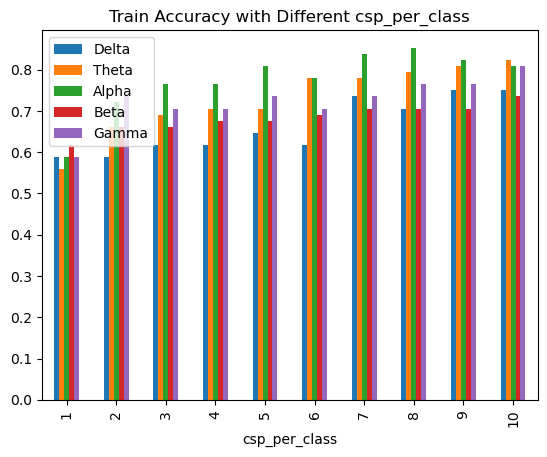

In [68]:
train_scores_df.plot(kind='bar',title='Train Accuracy with Different csp_per_class');

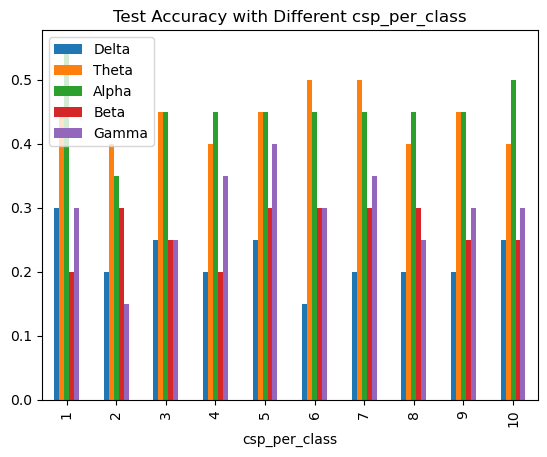

In [69]:
test_scores_df.plot(kind='bar',title='Test Accuracy with Different csp_per_class');

#### We observed the Theta and Alpha band prediction generally has high accurcy among these five bands. Which means, there might be key different behaviour in Theta and Alpha band among Alzheimer, Frontotemporal Dementia and Healthy subjects.

## CSP classification on Ratio of band

In [ ]:
def ratio_band_train_test(to_divide):
    # ============================== Divide a band within each subject each channel ================================
    ratio_data = []
    num_channel = 19
    to_divide = to_divide
    channel_dict = {'Delta':0, 'Theta':1, 'Alpha':2, 'Beta':3, 'Gamma':4}
    channel_divided_idx = channel_dict[to_divide]

    for subject in all_data:
        subject_temp = subject.copy()

        for ch in range(num_channel):
            temp = subject_temp.iloc[:,ch*5:ch*5+5]
            temp.iloc[:,0] = temp.iloc[:,0] / temp.iloc[:,channel_divided_idx]
            temp.iloc[:,1] = temp.iloc[:,1] / temp.iloc[:,channel_divided_idx]
            temp.iloc[:,2] = temp.iloc[:,2] / temp.iloc[:,channel_divided_idx]
            temp.iloc[:,3] = temp.iloc[:,3] / temp.iloc[:,channel_divided_idx]
            temp.iloc[:,4] = temp.iloc[:,4] / temp.iloc[:,channel_divided_idx]
            
            subject_temp.iloc[:,ch*5:ch*5+5] = temp

        subject_temp = subject_temp.drop(columns=subject_temp.columns[subject_temp.columns.str.contains(to_divide)])
        subject_temp.columns = subject_temp.columns + '/'+to_divide

        ratio_data.append(subject_temp)


    # ============================== Re-construct input structure to fit parameter shape ================================
    # "Delta" "Theta" "Alpha" "Beta" "Gamma"
    ratio_band_name = band_name.copy()
    ratio_band_name.remove(to_divide)
    ratio_band_name = [band_name+'/'+to_divide for band_name in ratio_band_name]

            # 0    1          # 0 AZ  1 FTD  2 Healthy
    # band -> train_test -> class(list of channel)
    ratio_band = [[[[],[],[]],[[],[],[]]],
                [[[],[],[]],[[],[],[]]],
                [[[],[],[]],[[],[],[]]],
                [[[],[],[]],[[],[],[]]],
                [[[],[],[]],[[],[],[]]]
                ]
    band_dictionary = {ratio_band_name[i]:i for i in range(len(ratio_band_name))}
    num_channel = 19


    for band in ratio_band_name:
        for subject in ratio_data:

            temp = [] # channel--datapoints
            current_band_df = subject[subject.columns[subject.columns.str.contains(band)]]  # eg. subject 1 Delta band

            for ch in range(num_channel):
                temp.append(current_band_df.iloc[:,ch].to_numpy())

            if subject['train_test/'+to_divide][0] == 'Train':
                ratio_band[band_dictionary[band]][0][subject['Label/'+to_divide][0]].append(temp)
            else:
                ratio_band[band_dictionary[band]][1][subject['Label/'+to_divide][0]].append(temp)


    # ================================== train test on data==================================
    train_scores = []
    test_scores = []
    n_filters = len(ratio_band_name)

    for csp_per_class in range(1,11):
        train_score, test_score = train_test(csp_per_class, n_filters, ratio_band)
        train_scores.append(train_score.mean(axis=0))
        test_scores.append(test_score.mean(axis=0))


    # ================================ aggregate train test score =======================================
    train_scores_df = pd.DataFrame(train_scores, columns=ratio_band_name)
    train_scores_df['csp_per_class'] = train_scores_df.index+1
    train_scores_df = train_scores_df.set_index('csp_per_class')

    test_scores_df = pd.DataFrame(test_scores, columns=ratio_band_name)
    test_scores_df['csp_per_class'] = test_scores_df.index+1
    test_scores_df = test_scores_df.set_index('csp_per_class')

    return train_scores_df, test_scores_df
    # # ================================ Plot ====================================
    # return train_scores_df.plot(kind='bar',title='Train Accuracy with Different csp_per_class (Ratio Band)'), test_scores_df.plot(kind='bar',title='Test Accuracy with Different csp_per_class (Ratio Band)');

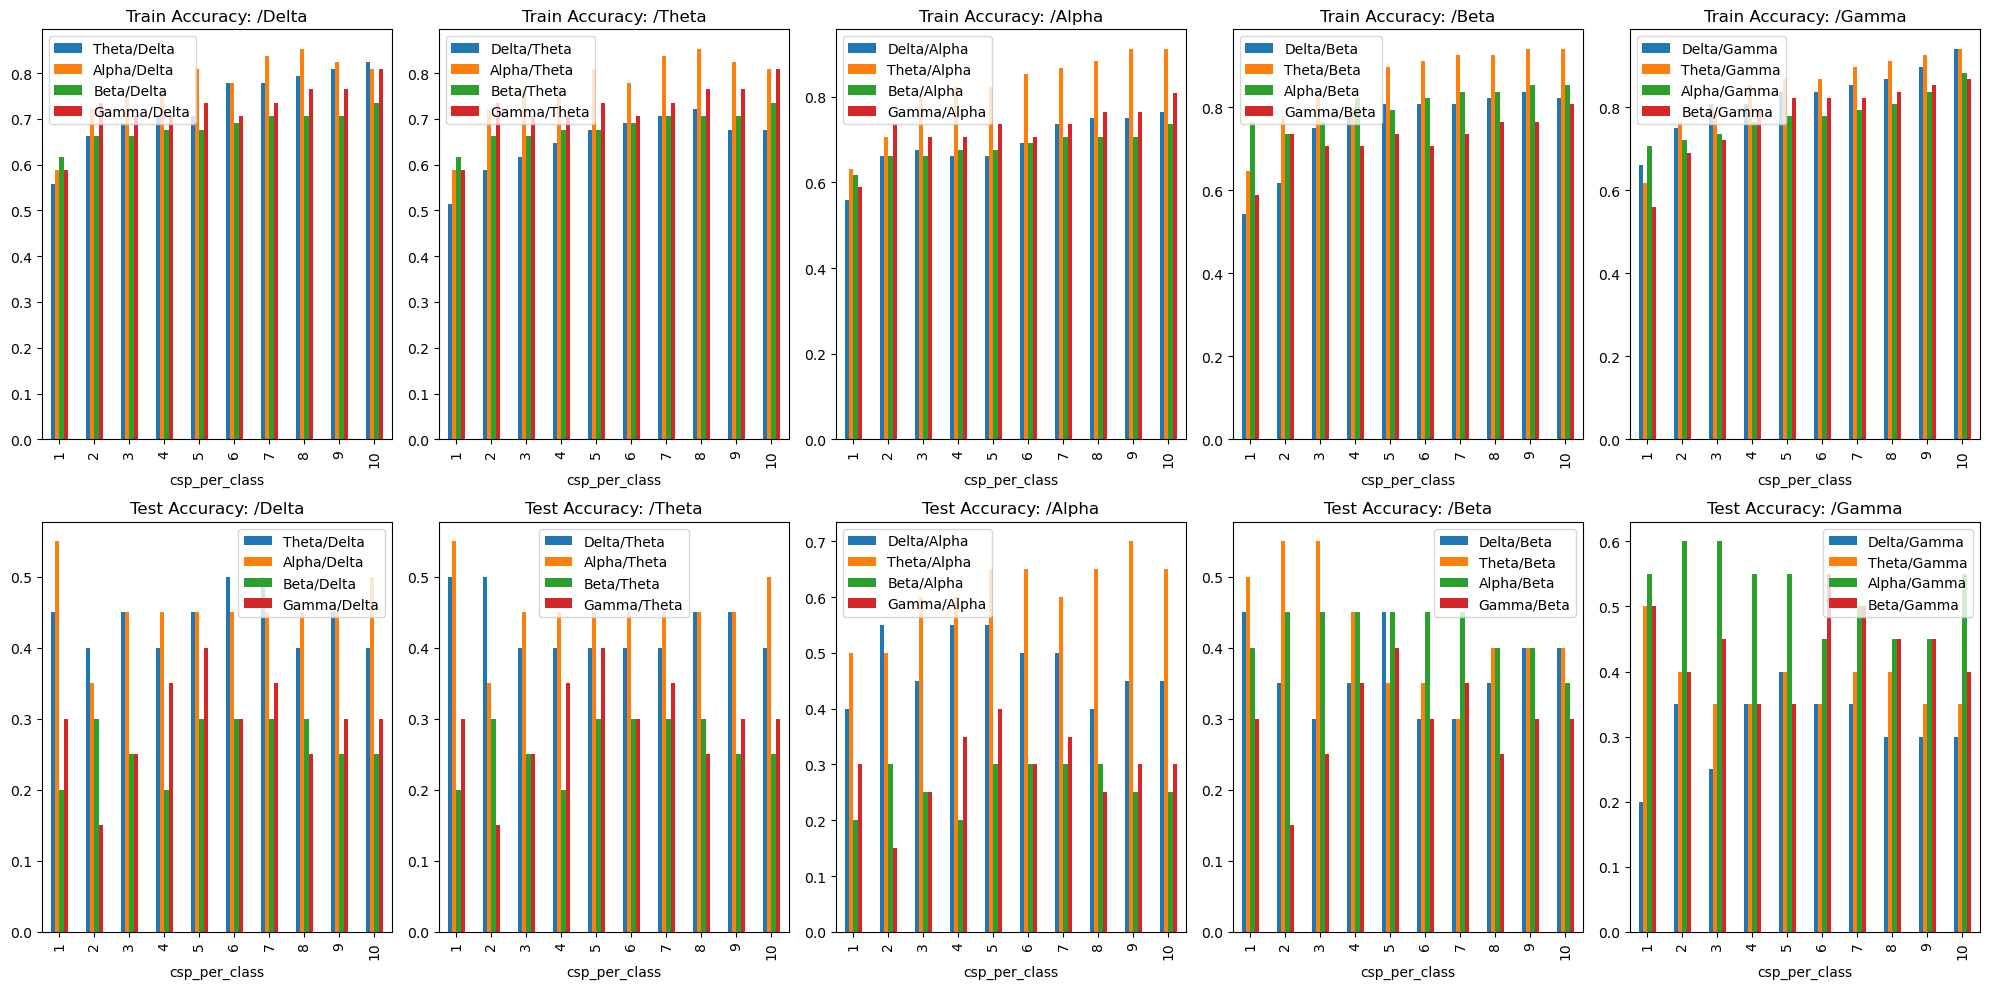

In [251]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))  # Create a 2-row, 5-column grid
axes = axes.flatten()  # Flatten for easy indexing

for i, band in enumerate(band_name):
    train_df, test_df = ratio_band_train_test(band)  # Get train & test data

    train_index = i  # Train plots go to row 1: index [0,1,2,3,4]
    test_index = i + 5  # Test plots go to row 2: index [5,6,7,8,9]

    train_df.plot(kind='bar', title=f'Train Accuracy: /{band}', ax=axes[train_index])  # Top row
    test_df.plot(kind='bar', title=f'Test Accuracy: /{band}', ax=axes[test_index])  # Bottom row

plt.tight_layout()  # Adjust layout
plt.show()  # Display all plots

In [219]:
# Experiment on Ratio of band instead band itself
# Divide Theta within each subject each channel
ratio_data = []
num_channel = 19
to_divide = 'Gamma'
channel_dict = {'Delta':0, 'Theta':1, 'Alpha':2, 'Beta':3, 'Gamma':4}
channel_divided_idx = channel_dict[to_divide]

for subject in all_data:
    subject_temp = subject.copy()

    for ch in range(num_channel):
        temp = subject_temp.iloc[:,ch*5:ch*5+5]
        temp.iloc[:,0] = temp.iloc[:,0] / temp.iloc[:,channel_divided_idx]
        temp.iloc[:,1] = temp.iloc[:,1] / temp.iloc[:,channel_divided_idx]
        temp.iloc[:,2] = temp.iloc[:,2] / temp.iloc[:,channel_divided_idx]
        temp.iloc[:,3] = temp.iloc[:,3] / temp.iloc[:,channel_divided_idx]
        temp.iloc[:,4] = temp.iloc[:,4] / temp.iloc[:,channel_divided_idx]
        
        subject_temp.iloc[:,ch*5:ch*5+5] = temp

    subject_temp = subject_temp.drop(columns=subject_temp.columns[subject_temp.columns.str.contains(to_divide)])
    subject_temp.columns = subject_temp.columns + '/'+to_divide

    ratio_data.append(subject_temp)

In [220]:
# "Delta" "Theta" "Alpha" "Beta" "Gamma"
ratio_band_name = band_name.copy()
ratio_band_name.remove(to_divide)
ratio_band_name = [band_name+'/'+to_divide for band_name in ratio_band_name]

          # 0    1          # 0 AZ  1 FTD  2 Healthy
# band -> train_test -> class(list of channel)
ratio_band = [[[[],[],[]],[[],[],[]]],
              [[[],[],[]],[[],[],[]]],
              [[[],[],[]],[[],[],[]]],
              [[[],[],[]],[[],[],[]]],
              [[[],[],[]],[[],[],[]]]
              ]
band_dictionary = {ratio_band_name[i]:i for i in range(len(ratio_band_name))}
num_channel = 19

In [221]:
for band in ratio_band_name:
    for subject in ratio_data:

        temp = [] # channel--datapoints
        current_band_df = subject[subject.columns[subject.columns.str.contains(band)]]  # eg. subject 1 Delta band

        for ch in range(num_channel):
            temp.append(current_band_df.iloc[:,ch].to_numpy())

        if subject['train_test/'+to_divide][0] == 'Train':
            ratio_band[band_dictionary[band]][0][subject['Label/'+to_divide][0]].append(temp)
        else:
            ratio_band[band_dictionary[band]][1][subject['Label/'+to_divide][0]].append(temp)


In [222]:
train_scores = []
test_scores = []
n_filters = len(ratio_band_name)

for csp_per_class in range(1,11):
    train_score, test_score = train_test(csp_per_class, n_filters, ratio_band)
    train_scores.append(train_score.mean(axis=0))
    test_scores.append(test_score.mean(axis=0))

In [223]:
train_scores_df = pd.DataFrame(train_scores, columns=ratio_band_name)
train_scores_df['csp_per_class'] = train_scores_df.index+1
train_scores_df = train_scores_df.set_index('csp_per_class')

test_scores_df = pd.DataFrame(test_scores, columns=ratio_band_name)
test_scores_df['csp_per_class'] = test_scores_df.index+1
test_scores_df = test_scores_df.set_index('csp_per_class')

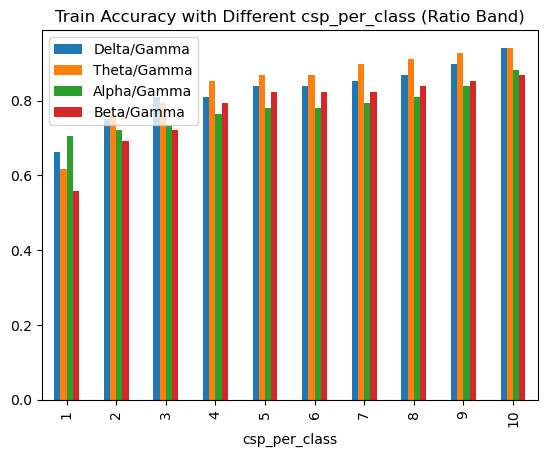

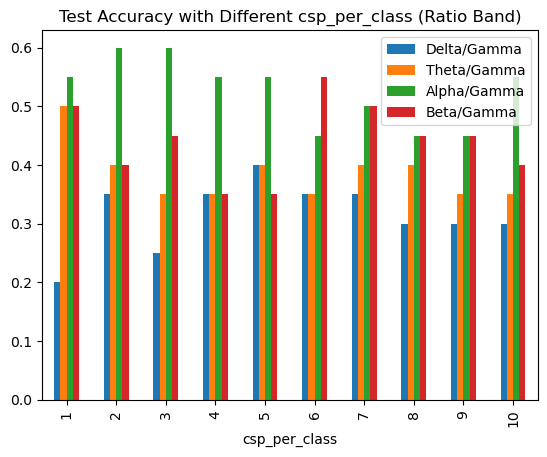

In [226]:
train_scores_df.plot(kind='bar',title='Train Accuracy with Different csp_per_class (Ratio Band)');
test_scores_df.plot(kind='bar',title='Test Accuracy with Different csp_per_class (Ratio Band)');

In [94]:
all_data[0].iloc[:,0:5].columns

Index(['Fp1_Delta', 'Fp1_Theta', 'Fp1_Alpha', 'Fp1_Beta', 'Fp1_Gamma'], dtype='object')

In [129]:
temp = all_data[0].iloc[:,0:5]
temp

,Fp1_Delta,Fp1_Theta,Fp1_Alpha,Fp1_Beta,Fp1_Gamma
0,7.263740e+07,7.401726e+06,1.397078e+06,772635.805467,379332.503343
1,7.833394e+07,5.628908e+06,1.113290e+06,729217.663268,416159.821683
2,6.774954e+07,8.890081e+06,1.314347e+06,611290.852219,389898.478761
3,6.390395e+07,8.594520e+06,1.369575e+06,531119.984418,412718.463915
4,1.091872e+08,5.691749e+06,1.777312e+06,833091.620683,397785.688619
...,...,...,...,...,...
113,9.960512e+07,5.429625e+06,1.833418e+06,530228.695290,200628.455193
114,6.943211e+07,8.720280e+06,1.559019e+06,629812.047036,207708.926492
115,5.102649e+07,1.193560e+07,1.343596e+06,632378.088162,191781.569876
116,5.249842e+07,7.703655e+06,1.570298e+06,572842.832307,156036.971249


In [130]:
# Delta/Theta, Alpha/Theta, Beta/Theta, Gamma/Theta
temp.iloc[:,0] = temp.iloc[:,0] / temp.iloc[:,1]
temp.iloc[:,1] = temp.iloc[:,1] / temp.iloc[:,1]
temp.iloc[:,2] = temp.iloc[:,2] / temp.iloc[:,1]
temp.iloc[:,3] = temp.iloc[:,3] / temp.iloc[:,1]
temp.iloc[:,4] = temp.iloc[:,4] / temp.iloc[:,1]
temp

,Fp1_Delta,Fp1_Theta,Fp1_Alpha,Fp1_Beta,Fp1_Gamma
0,9.813576,1.0,1.397078e+06,772635.805467,379332.503343
1,13.916364,1.0,1.113290e+06,729217.663268,416159.821683
2,7.620801,1.0,1.314347e+06,611290.852219,389898.478761
3,7.435430,1.0,1.369575e+06,531119.984418,412718.463915
4,19.183421,1.0,1.777312e+06,833091.620683,397785.688619
...,...,...,...,...,...
113,18.344750,1.0,1.833418e+06,530228.695290,200628.455193
114,7.962142,1.0,1.559019e+06,629812.047036,207708.926492
115,4.275152,1.0,1.343596e+06,632378.088162,191781.569876
116,6.814742,1.0,1.570298e+06,572842.832307,156036.971249


In [136]:
t1 = all_data[0].copy()
num_channel = 19
for ch in range(num_channel):
    temp = t1.iloc[:,ch*5:ch*5+5]
    temp.iloc[:,0] = temp.iloc[:,0] / temp.iloc[:,1]
    temp.iloc[:,1] = temp.iloc[:,1] / temp.iloc[:,1]
    temp.iloc[:,2] = temp.iloc[:,2] / temp.iloc[:,1]
    temp.iloc[:,3] = temp.iloc[:,3] / temp.iloc[:,1]
    temp.iloc[:,4] = temp.iloc[:,4] / temp.iloc[:,1]
    
    t1.iloc[:,ch*5:ch*5+5] = temp
t1 = t1.drop(columns=t1.columns[t1.columns.str.contains('Theta')])
t1.columns = t1.columns + '/Theta'

In [137]:
t1

,Fp1_Delta/Theta,Fp1_Alpha/Theta,Fp1_Beta/Theta,Fp1_Gamma/Theta,Fp2_Delta/Theta,Fp2_Alpha/Theta,Fp2_Beta/Theta,Fp2_Gamma/Theta,F3_Delta/Theta,F3_Alpha/Theta,...,Cz_Delta/Theta,Cz_Alpha/Theta,Cz_Beta/Theta,Cz_Gamma/Theta,Pz_Delta/Theta,Pz_Alpha/Theta,Pz_Beta/Theta,Pz_Gamma/Theta,Label/Theta,train_test/Theta
0,9.813576,1.397078e+06,772635.805467,379332.503343,10.371179,1.246814e+06,694346.271987,270060.150959,11.753384,9.514815e+05,...,11.209430,7.542072e+05,469607.959012,92087.670902,9.178844,8.188759e+05,406379.909372,73792.630890,0,Train
1,13.916364,1.113290e+06,729217.663268,416159.821683,12.437399,1.051979e+06,653349.687862,304095.549930,11.085667,8.234464e+05,...,10.431563,8.904608e+05,474687.381744,106763.659069,9.336604,1.358872e+06,454421.620247,84153.160532,0,Train
2,7.620801,1.314347e+06,611290.852219,389898.478761,6.677749,1.160568e+06,507552.009133,295344.058561,9.096330,8.964894e+05,...,10.161419,9.803616e+05,366255.162314,92040.433386,8.691948,1.704490e+06,323739.059911,73094.968327,0,Train
3,7.435430,1.369575e+06,531119.984418,412718.463915,6.814722,1.273355e+06,426448.227278,302096.020379,9.248195,1.032060e+06,...,9.212590,9.009758e+05,350390.464230,97554.446271,7.724284,1.316902e+06,356681.464571,83580.305717,0,Train
4,19.183421,1.777312e+06,833091.620683,397785.688619,21.079688,1.422113e+06,668980.575431,275563.922298,21.955768,1.216809e+06,...,20.467190,1.206451e+06,416310.162327,82891.799438,19.935825,1.587328e+06,441780.192420,63130.277064,0,Train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,18.344750,1.833418e+06,530228.695290,200628.455193,19.776936,1.700484e+06,476072.542987,144949.702642,30.930518,1.679099e+06,...,31.743803,1.449976e+06,359380.552496,95123.557760,17.591549,1.539832e+06,389095.811721,85002.613474,0,Train
114,7.962142,1.559019e+06,629812.047036,207708.926492,7.259246,1.550396e+06,595936.605121,151919.380431,8.154145,1.431402e+06,...,9.492959,1.413399e+06,438202.856527,80143.348026,7.570978,1.910344e+06,416460.318092,86204.318413,0,Train
115,4.275152,1.343596e+06,632378.088162,191781.569876,4.012082,1.235443e+06,597360.253428,141880.568154,4.317054,1.195959e+06,...,5.011965,1.429753e+06,476713.984137,88436.641935,5.629691,2.020018e+06,468357.698800,78488.860216,0,Train
116,6.814742,1.570298e+06,572842.832307,156036.971249,7.096450,1.578484e+06,501035.026117,125426.485178,7.691399,1.511830e+06,...,6.921354,1.359390e+06,430671.945173,90542.346808,5.878052,1.693273e+06,402287.813845,69526.631127,0,Train


In [112]:
temp.drop(columns=temp.columns[1]).columns + '/Theta'

Index(['Fp1_Delta/Theta', 'Fp1_Alpha/Theta', 'Fp1_Beta/Theta',
       'Fp1_Gamma/Theta'],
      dtype='object')